# Lumbar Spine MRI Analysis with MedGemma

This notebook demonstrates how to work with **DICOM medical images** from the [RSNA 2024 Lumbar Spine Degenerative Classification](https://www.kaggle.com/competitions/rsna-2024-lumbar-spine-degenerative-classification) competition and use a locally hosted **MedGemma-4b** model (via LM Studio) for AI-assisted radiological analysis.

## Learning objectives
1. Understand the **DICOM** image format used in clinical radiology
2. Load, inspect, and visualize **lumbar spine MRI** series (Sagittal T1, Sagittal T2/STIR, Axial T2)
3. Perform window/level normalization to display MRI contrast correctly
4. Build multimodal prompts and call the **MedGemma** API for radiological interpretation
5. Compare AI analysis across different MRI series types

## Clinical context
The five degenerative conditions evaluated in this competition are:

| Condition | What it means |
| :--- | :--- |
| **Spinal Canal Stenosis** | Narrowing of the central canal compressing the spinal cord/cauda equina |
| **Left Neural Foraminal Narrowing** | Left exit channel for nerve roots is compressed |
| **Right Neural Foraminal Narrowing** | Right exit channel for nerve roots is compressed |
| **Left Subarticular Stenosis** | Left lateral recess narrowing compressing nerve roots |
| **Right Subarticular Stenosis** | Right lateral recess narrowing compressing nerve roots |

Each condition is assessed at five intervertebral disc levels: **L1/L2, L2/L3, L3/L4, L4/L5, L5/S1**, with severity graded as **Normal/Mild**, **Moderate**, or **Severe**.

---
## Data download
Download the competition dataset from Kaggle (requires acceptance of competition rules):
```bash
# Install Kaggle CLI if needed
pip install kaggle

# Place your kaggle.json API key in ~/.kaggle/kaggle.json, then:
kaggle competitions download -c rsna-2024-lumbar-spine-degenerative-classification -p ./data/rsna-2024-lumbar-spine/
cd ./data/rsna-2024-lumbar-spine/ && unzip rsna-2024-lumbar-spine-degenerative-classification.zip
```
Expected directory layout after extraction:
```
data/rsna-2024-lumbar-spine/
├── train.csv
├── train_label_coordinates.csv
├── train_series_descriptions.csv
└── train_images/
    └── <study_id>/
        └── <series_id>/
            └── <instance_number>.dcm
```

 #### The connections between the studies and the series of a study:

1. One study is composed of multiple series that are aquired within one session.

2. Series are set of images, usually aquired in one run 

3. The images of each series depict a given volume of the spine - different series might overlap each other but not necesarily completely

## 🔧 Install dependencies

Run this cell once to install all required packages into the current kernel.

In [ ]:
# Uncomment and run if packages are not yet installed
# %pip install pydicom pillow matplotlib numpy pandas requests ipywidgets

## 📦 Imports

In [1]:
import base64
import io
import mimetypes
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pydicom
import requests
from PIL import Image
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

try:
    import ipywidgets as widgets
    from IPython.display import clear_output
    widgets_available = True
except ImportError:
    widgets_available = False

print(f"pydicom version : {pydicom.__version__}")
print(f"Pillow version  : {Image.__version__}")
print(f"Widgets available: {widgets_available}")

pydicom version : 3.0.2
Pillow version  : 11.1.0
Widgets available: True


## ⚙️ Runtime configuration

The notebook calls the **LM Studio OpenAI-compatible endpoint** running on your Windows 11 host.
Set `LM_STUDIO_BASE_URL` to match your Windows host IP as seen from WSL (typically the gateway address).

```bash
# Find Windows host IP from WSL:
cat /etc/resolv.conf | grep nameserver
# or
ip route | grep default
```
Override these defaults by setting environment variables before launching Jupyter:
```bash
export LM_STUDIO_BASE_URL=http://192.168.1.2:1234/v1
export LM_STUDIO_MODEL=medgemma-4b-it
```

In [3]:
LM_STUDIO_BASE_URL = os.getenv("LM_STUDIO_BASE_URL", "http://192.168.1.2:1234/v1")
LM_STUDIO_MODEL    = os.getenv("LM_STUDIO_MODEL",    "medgemma-4b-it")

# Root folder of the RSNA dataset
RSNA_DATA_ROOT = Path("./data/rsna_study_100206310")

print(f"LM Studio endpoint : {LM_STUDIO_BASE_URL}")
print(f"Model              : {LM_STUDIO_MODEL}")
print(f"RSNA data root     : {RSNA_DATA_ROOT.resolve()}")
print(f"Data root exists   : {RSNA_DATA_ROOT.exists()}")

LM Studio endpoint : http://192.168.1.2:1234/v1
Model              : medgemma-4b-it
RSNA data root     : /home/bk_anupam/code/ML/DeepLearningWSL/Training/AI_In_HealthCare/ImageDiagnosis/data/rsna_study_100206310
Data root exists   : True


---

## 🗂️ What is DICOM?

**DICOM** (Digital Imaging and Communications in Medicine) is the universal standard for storing, transmitting, and displaying medical imaging data. Every MRI, CT scan, or X-ray produced in a modern hospital is stored as a DICOM file.

### Why DICOM instead of JPEG/PNG?

| Property | JPEG/PNG | DICOM (.dcm) |
| :--- | :--- | :--- |
| **Bit depth** | 8-bit (256 levels) | 12–16-bit (4,096–65,536 levels) |
| **Metadata** | Minimal (EXIF) | Rich: patient ID, acquisition params, orientation |
| **Multi-frame** | No | Yes — a single file can hold a 3D volume |
| **Coordinate system** | Pixel-only | Voxel, Physical world coordinates (mm) |
| **Clinical use** | Never used in radiology | Mandatory standard globally |

### Key DICOM metadata fields

```
StudyInstanceUID      → unique identifier for the entire imaging study
SeriesInstanceUID     → unique identifier for one series of images
SOPInstanceUID        → unique identifier for a single image slice
Modality              → MR, CT, CR, DX, …
SeriesDescription     → e.g. "Sagittal T2/STIR", "Axial T2"
ImagePositionPatient  → 3D position (x, y, z) in mm of the first voxel
ImageOrientationPatient → direction cosines defining the image plane
PixelSpacing          → physical size of each pixel in mm
RescaleIntercept/Slope → converts stored integers → Hounsfield Units (CT) or a.u. (MR)
WindowCenter/Width    → radiologist's display window preset
```

### MRI series used in lumbar spine studies

| Series | Plane | Best for |
| :--- | :--- | :--- |
| **Sagittal T1** | Side view | Vertebral body height, fatty marrow, alignment |
| **Sagittal T2/STIR** | Side view | Disc hydration, spinal canal, cord signal |
| **Axial T2** | Top-down cross-section | Foraminal narrowing, lateral recess, central canal |

> In T2-weighted MRI, **fluid appears bright** (white) — healthy discs are bright because they contain water-rich nucleus pulposus. Degenerated discs appear dark.

---

## 📋 Explore the dataset metadata

In [4]:
def load_csv_if_exists(path: Path, label: str) -> pd.DataFrame | None:
    if path.exists():
        df = pd.read_csv(path)
        print(f"\n{'='*60}")
        print(f"  {label}  ({path.name})")
        print(f"{'='*60}")
        print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
        display(df.head(3))
        return df
    else:
        print(f"[MISSING] {path} — download the dataset first.")
        return None


df_train       = load_csv_if_exists(RSNA_DATA_ROOT / "metadata/train.csv",                    "Train labels")
df_series      = load_csv_if_exists(RSNA_DATA_ROOT / "metadata/train_series_descriptions.csv", "Series descriptions")
df_coords      = load_csv_if_exists(RSNA_DATA_ROOT / "metadata/train_label_coordinates.csv",   "Label coordinates")


  Train labels  (train.csv)
Shape: 1 rows × 26 columns


,study_id,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
0,100206310,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Severe,...,Normal/Mild,Normal/Mild,Moderate,Severe,Moderate,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate



  Series descriptions  (train_series_descriptions.csv)
Shape: 3 rows × 3 columns


,study_id,series_id,series_description
0,100206310,1012284084,Axial T2
1,100206310,1792451510,Sagittal T2/STIR
2,100206310,2092806862,Sagittal T1



  Label coordinates  (train_label_coordinates.csv)
Shape: 25 rows × 7 columns


,study_id,series_id,instance_number,condition,level,x,y
0,100206310,1012284084,20,Left Subarticular Stenosis,L1/L2,180.355677,165.034200
1,100206310,1012284084,20,Right Subarticular Stenosis,L1/L2,145.120536,162.285714
2,100206310,1012284084,28,Left Subarticular Stenosis,L2/L3,177.729138,160.218878


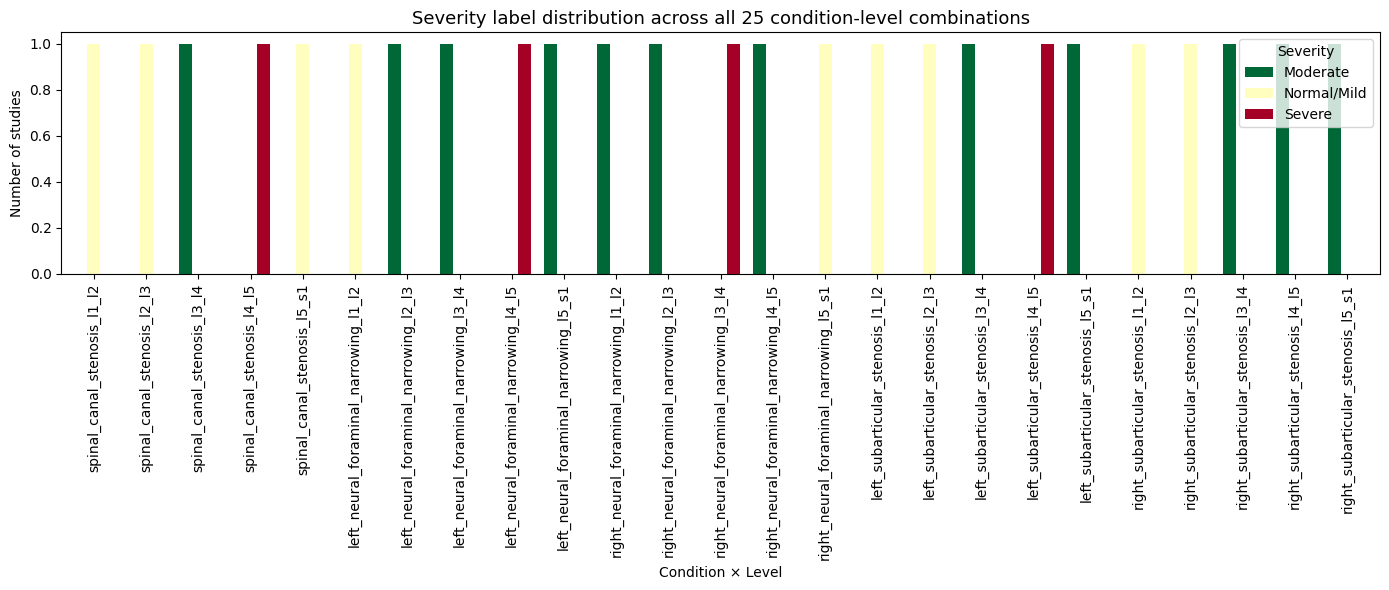


Series description counts:
series_description
Axial T2            1
Sagittal T2/STIR    1
Sagittal T1         1


In [6]:
# ── Distribution of severity labels across all conditions ──────────────────
if df_train is not None:
    condition_cols = [c for c in df_train.columns if c != "study_id"]
    severity_counts = (
        df_train[condition_cols]
        .apply(pd.Series.value_counts)
        .T
        .fillna(0)
        .astype(int)
    )
    fig, ax = plt.subplots(figsize=(14, 6))
    severity_counts.plot(kind="bar", ax=ax, colormap="RdYlGn_r", width=0.75)
    ax.set_title("Severity label distribution across all 25 condition-level combinations", fontsize=13)
    ax.set_xlabel("Condition × Level")
    ax.set_ylabel("Number of studies")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(title="Severity")
    plt.tight_layout()
    plt.show()
else:
    print("Label distribution chart: requires train.csv")

# ── Series type distribution ────────────────────────────────────────────────
if df_series is not None:
    print("\nSeries description counts:")
    print(df_series["series_description"].value_counts().to_string())

---

## 🩻 DICOM loading and metadata inspection

The helper functions below demonstrate the core DICOM workflow:
1. Read a `.dcm` file with `pydicom.dcmread()`
2. Inspect the embedded metadata tags
3. Extract the raw pixel array and apply calibration

In [7]:
# ── Helpers ────────────────────────────────────────────────────────────────

def load_dicom(path: Path) -> pydicom.Dataset:
    """Load a DICOM file and return the dataset."""
    return pydicom.dcmread(str(path))


def print_dicom_metadata(ds: pydicom.Dataset) -> None:
    """Print a curated subset of clinically relevant DICOM tags."""
    tags_of_interest = [
        ("PatientID",              "Patient ID"),
        ("StudyDate",              "Study date"),
        ("Modality",               "Modality"),
        ("SeriesDescription",      "Series description"),
        ("BodyPartExamined",       "Body part"),
        ("StudyDescription",       "Study description"),
        ("Rows",                   "Image rows (px)"),
        ("Columns",                "Image cols (px)"),
        ("PixelSpacing",           "Pixel spacing (mm)"),
        ("SliceThickness",         "Slice thickness (mm)"),
        ("SpacingBetweenSlices",   "Slice spacing (mm)"),
        ("ImagePositionPatient",   "Image position (mm)"),
        ("ImageOrientationPatient","Image orientation"),
        ("WindowCenter",           "Window center"),
        ("WindowWidth",            "Window width"),
        ("RescaleSlope",           "Rescale slope"),
        ("RescaleIntercept",       "Rescale intercept"),
        ("BitsStored",             "Bits stored"),
        ("InstanceNumber",         "Instance number"),
    ]
    print(f"\n{'DICOM Metadata':=^55}")
    for attr, label in tags_of_interest:
        value = getattr(ds, attr, "— not present —")
        print(f"  {label:<30}: {value}")
    print(f"{'':=<55}")


def get_pixel_array(ds: pydicom.Dataset) -> np.ndarray:
    """
    Return calibrated pixel values.
    Applies RescaleSlope / RescaleIntercept if present.
    For MRI these are usually 1 / 0, but good practice to handle them.
    """
    pixels = ds.pixel_array.astype(np.float32)
    slope  = float(getattr(ds, "RescaleSlope",     1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    return pixels * slope + intercept


print("DICOM helper functions defined.")

DICOM helper functions defined.


In [8]:
# ── Find a sample DICOM file ───────────────────────────────────────────────
sample_dcm_path: Path | None = None

train_images_dir = RSNA_DATA_ROOT / "train_images"
if train_images_dir.exists():
    dcm_files = sorted(train_images_dir.rglob("*.dcm"))
    if dcm_files:
        sample_dcm_path = dcm_files[23]
        print(f"Found {len(dcm_files):,} DICOM files")
        print(f"Sample file: {sample_dcm_path}")
    else:
        print("No .dcm files found under train_images/")
else:
    print(f"train_images/ directory not found at {train_images_dir}")
    print("Download the dataset and update RSNA_DATA_ROOT to continue.")

# If running without dataset, point to any local .dcm you have for exploration:
# sample_dcm_path = Path("/path/to/your/file.dcm")

Found 96 DICOM files
Sample file: data/rsna_study_100206310/train_images/100206310/1012284084/30.dcm


In [9]:
if sample_dcm_path is not None:
    sample_ds = load_dicom(sample_dcm_path)
    print_dicom_metadata(sample_ds)
    pixels = get_pixel_array(sample_ds)
    print(f"\nPixel array shape : {pixels.shape}")
    print(f"Value range       : [{pixels.min():.0f}, {pixels.max():.0f}]")
    print(f"Mean / std        : {pixels.mean():.1f} / {pixels.std():.1f}")
else:
    print("No DICOM file available — skipping metadata display.")


====================DICOM Metadata=====================
  Patient ID                    : 100206310
  Study date                    : — not present —
  Modality                      : — not present —
  Series description            : T2
  Body part                     : — not present —
  Study description             : — not present —
  Image rows (px)               : 320
  Image cols (px)               : 320
  Pixel spacing (mm)            : [0.5, 0.5]
  Slice thickness (mm)          : 3.5
  Slice spacing (mm)            : 3.5
  Image position (mm)           : [-68.457000270588, -18.64606850324, -503.40558143906]
  Image orientation             : [0.99945175454685, 0.01736033512124, -0.028192358853, -0.0202374615946, 0.99424473602827, -0.1052038498738]
  Window center                 : 422
  Window width                  : 960
  Rescale slope                 : — not present —
  Rescale intercept             : — not present —
  Bits stored                   : 12
  Instance number     

## 1. The Basics (Identity & Context)
*   **Patient ID (100206310):** A unique string to identify the patient. In your **Swasthya-Sahayak** project, this is a primary candidate for PII redaction.
*   **Series Description (T2):** This tells you the MRI "flavor." **T2-weighted** images make fluid (like spinal fluid or edema) appear bright white, which is great for spotting inflammation or pathology.
*   **Instance Number (30):** This is effectively the "page number." It means this specific image is the 30th slice in the T2 sequence.

---

## 2. Spatial Geometry (The "Where")
These attributes define the physical dimensions of the tissue being imaged.

*   **Image Rows/Cols (320, 320):** The resolution of the digital grid. Your image is a matrix of $320 \times 320$ pixels.
*   **Pixel Spacing (0.5, 0.5):** The physical size of a single pixel. Each pixel represents a $0.5 \text{ mm} \times 0.5 \text{ mm}$ area of real human tissue. 
*   **Slice Thickness (3.5 mm):** This adds the 3rd dimension (Z-axis). It means the "camera" captured a slab of tissue 3.5 mm thick.
*   **Slice Spacing (3.5 mm):** The distance from the center of one slice to the center of the next. Since this equals the thickness, it means there are no gaps between your slices (a "contiguous" scan).



---

## 3. Coordinate System (The "How it’s Oriented")
This is the most complex part of DICOM. It uses a **Patient Coordinate System** (Left-Posterior-Superior or LPS).

*   **Image Position (LPS):** The $(x, y, z)$ coordinates of the very first pixel (top-left) in the image relative to the magnet's center.
    *   `[-68.45, -18.64, -503.40]` tells the computer exactly where this slice sits in 3D space.
*   **Image Orientation:** These are "Direction Cosines." They are two unit vectors that tell the computer which way is "right" and which way is "down" relative to the patient.
    *   The first three numbers represent the row direction.
    *   The second three represent the column direction.
    *   *Calculation:* By looking at these, an algorithm can determine if the slice is **Axial, Sagittal, or Coronal**.



---

## 4. Visual Presentation (The "Contrast")
MRI scanners capture a huge range of data, but computer monitors can only show about 256 shades of gray. These tags tell the viewer which part of the data to focus on.

*   **Window Center (422):** Also called the "Level." It’s the midpoint brightness of the image.
*   **Window Width (960):** The range of pixel values being displayed.
    *   *How it works:* Any pixel value below $422 - (960/2)$ appears black. Any value above $422 + (960/2)$ appears white. Everything in between is a shade of gray.
*   **Bits Stored (12):** This defines the "depth." Your image uses 12 bits per pixel, meaning it can record $2^{12} = 4096$ unique intensities. This is much higher than a standard JPEG (8 bits).



---

## 5. Pixel Array Stats
*   **Value Range [0, 1177]:** The darkest pixel is 0, and the brightest is 1177. Note that since your **Bits Stored** is 12, the maximum possible value could have been 4095.
*   **Mean / Std (176.0 / 177.4):** This gives you a mathematical "vibe check" of the image. A standard deviation (177.4) that is nearly equal to the mean (176.0) suggests an image with high contrast—typical for T2 MRIs where you have very dark areas (bone/air) and very bright areas (fluid).

---

## 🖼️ Window / Level normalization

While the MRI hardware captures a massive dynamic range (e.g., 0 to 4095 in a 12-bit scan), our computer monitors and our eyes can only effectively process 8 bits (256 shades of gray). Windowing is the process of selecting a "subset" of that high-precision data and stretching it to fill the 0–255 range.

Raw MRI pixel values span a wide dynamic range (e.g. 0–4095 for a 12-bit scan). To display the image meaningfully and isolate clinically relevant contrast, radiologists apply a **Window / Level** (W/L) transformation:

$$
I_{\text{display}} = \frac{I_{\text{raw}} - \left(\text{Level} - \dfrac{\text{Window}}{2}\right)}{\text{Window}} \times 255
$$

- **Level** (Window Center): the midpoint intensity of the range of interest
- **Window** (Window Width): the span of intensities mapped to the full 0–255 display range

Values below the lower bound become black; values above become white. This is how radiologists 
 when reading scans on a PACS workstation.

 ## Why is this used? (The "Clinical" Why)
In a single MRI slice, there is too much information for a human to see at once. Radiologists "toggle" windows to look for different pathologies.

1.  **Brain Window:** A narrow width focused on the gray/white matter to look for subtle strokes or tumors.
2.  **Bone Window:** A very high level and wide width. This "blows out" the soft tissue (making it all look white/blurry) so that the fine details of the bone cortex become visible.
3.  **Subdural Window:** Used specifically to find blood right next to the skull; the settings are adjusted so that the "white" of the bone and the "white" of the blood look different.

In [10]:
def apply_window_level(
    pixels: np.ndarray,
    window: float | None = None,
    level: float | None = None,
) -> np.ndarray:
    """
    Apply window/level (W/L) contrast stretching and return an 8-bit array.
    If window and level are None, auto-scales using the image's own percentiles.
    """
    if window is None or level is None:
        low  = np.percentile(pixels, 1)
        high = np.percentile(pixels, 99)
        window = high - low
        level  = (high + low) / 2.0

    lower = level - window / 2.0
    upper = level + window / 2.0
    stretched = np.clip(pixels, lower, upper)
    stretched = (stretched - lower) / (upper - lower + 1e-8) * 255.0
    return stretched.astype(np.uint8)


def dicom_to_pil(ds: pydicom.Dataset, window: float | None = None, level: float | None = None) -> Image.Image:
    """
    Convert a DICOM dataset to a PIL Image with optional window/level control.
    Handles grayscale and RGB DICOM images.
    """
    pixels = get_pixel_array(ds)

    if pixels.ndim == 2:  # grayscale
        if window is not None and level is not None:
            # Use DICOM WindowCenter/Width if stored
            wc = float(getattr(ds, "WindowCenter", level))
            ww = float(getattr(ds, "WindowWidth",  window))
            if isinstance(wc, pydicom.sequence.Sequence):
                wc = float(wc[0])
                ww = float(ww[0])
            normed = apply_window_level(pixels, ww, wc)
        else:
            normed = apply_window_level(pixels)
        return Image.fromarray(normed, mode="L").convert("RGB")

    # RGB case
    normed = apply_window_level(pixels)
    return Image.fromarray(normed, mode="RGB")


print("Window/level helpers defined.")

Window/level helpers defined.


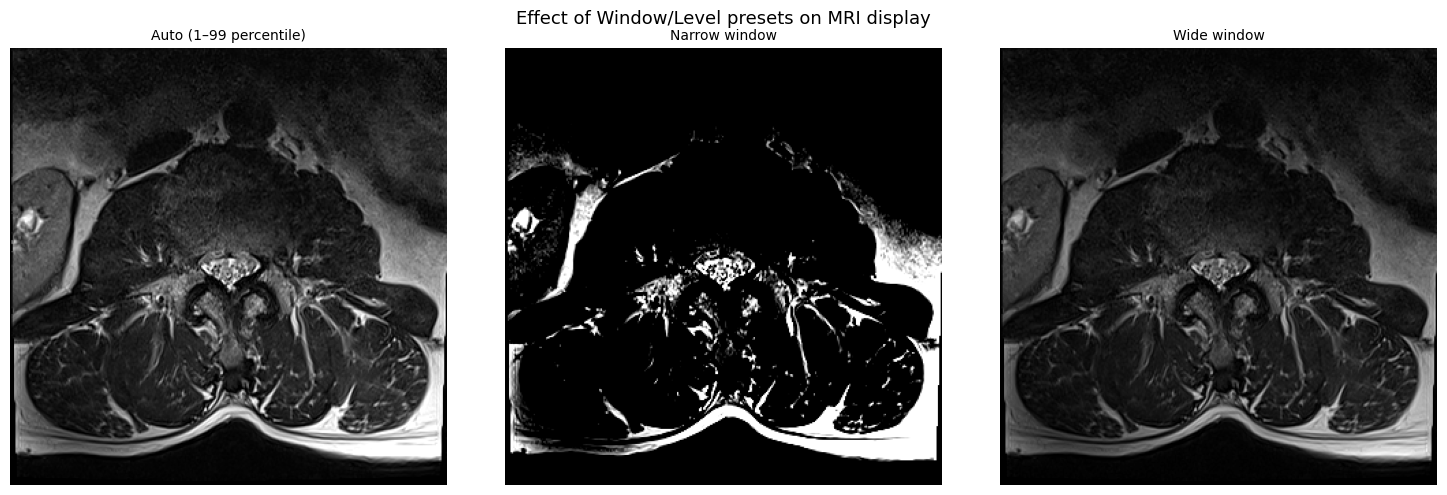

In [11]:
# ── Compare window/level presets on a single slice ──────────────────────────
if sample_dcm_path is not None:
    pixels = get_pixel_array(sample_ds)

    wl_presets = [
        ("Auto (1–99 percentile)", None,  None),
        ("Narrow window",          200,   400),
        ("Wide window",            2000,  1000),
    ]

    fig, axes = plt.subplots(1, len(wl_presets), figsize=(15, 5))
    fig.suptitle("Effect of Window/Level presets on MRI display", fontsize=13)

    for ax, (label, window, level) in zip(axes, wl_presets):
        normed = apply_window_level(pixels, window, level)
        ax.imshow(normed, cmap="gray")
        ax.set_title(label, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No DICOM file available — skipping window/level demo.")

---

## 📚 Visualizing a 3D MRI volume (multi-slice viewer)

Each MRI series consists of many parallel slices that together form a 3D volume.
The widget below lets you scroll through the stack interactively.

In [12]:
def load_series_volume(
    series_dir: Path,
    max_slices: int = 60,
) -> tuple[list[np.ndarray], list[pydicom.Dataset]]:
    """
    Load all DICOM slices from a series directory, sorted by InstanceNumber.
    Returns (list_of_pixel_arrays, list_of_datasets).
    """
    dcm_files = sorted(series_dir.glob("*.dcm"))
    if not dcm_files:
        return [], []

    datasets = [pydicom.dcmread(str(f)) for f in dcm_files[:max_slices]]
    # Sort by InstanceNumber if available
    datasets.sort(key=lambda ds: int(getattr(ds, "InstanceNumber", 0)))
    pixel_arrays = [get_pixel_array(ds) for ds in datasets]
    return pixel_arrays, datasets


def show_series_contact_sheet(
    pixel_arrays: list[np.ndarray],
    series_description: str = "",
    cols: int = 6,
) -> None:
    """Display all slices of a series as a contact sheet."""
    n = len(pixel_arrays)
    if n == 0:
        print("No slices to display.")
        return
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = np.array(axes).flatten()
    fig.suptitle(f"{series_description}  ({n} slices)", fontsize=12)

    for idx, pixels in enumerate(pixel_arrays):
        normed = apply_window_level(pixels)
        axes[idx].imshow(normed, cmap="gray")
        axes[idx].set_title(f"#{idx+1}", fontsize=7)
        axes[idx].axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


print("Volume loading helpers defined.")

Volume loading helpers defined.


Loading series: Sagittal T2/STIR
  Study ID : 100206310
  Series ID: 1792451510
  Path     : data/rsna_study_100206310/train_images/100206310/1792451510

Loaded 18 slices. Series: T2


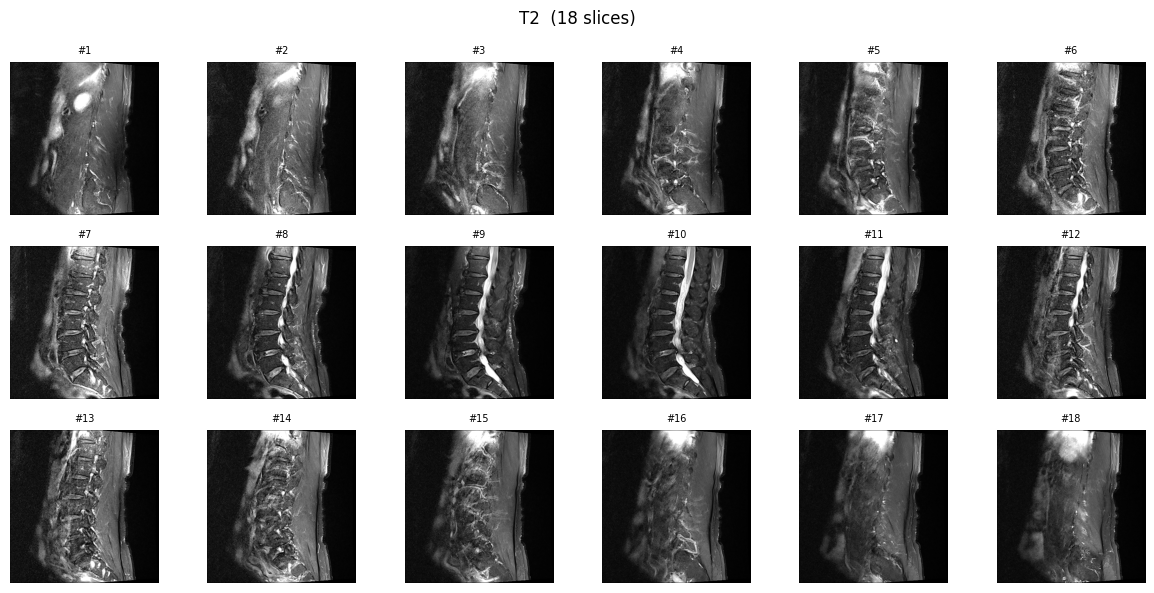

In [13]:
# ── Load and display a full series volume ───────────────────────────────────
selected_series_dir: Path | None = None

if df_series is not None and train_images_dir.exists():
    # Pick the first Sagittal T2/STIR series found in the dataset
    t2_rows = df_series[df_series["series_description"].str.contains("Sagittal T2", case=False, na=False)]
    if not t2_rows.empty:
        row       = t2_rows.iloc[0]
        study_id  = str(row["study_id"])
        series_id = str(row["series_id"])
        selected_series_dir = train_images_dir / study_id / series_id
        print(f"Loading series: {row['series_description']}")
        print(f"  Study ID : {study_id}")
        print(f"  Series ID: {series_id}")
        print(f"  Path     : {selected_series_dir}")
    else:
        print("No Sagittal T2 series found — trying first available series.")
        row       = df_series.iloc[0]
        study_id  = str(row["study_id"])
        series_id = str(row["series_id"])
        selected_series_dir = train_images_dir / study_id / series_id
elif sample_dcm_path is not None:
    selected_series_dir = sample_dcm_path.parent
    print(f"Using parent directory of sample file: {selected_series_dir}")
else:
    print("No DICOM data available.")


# Load and display
if selected_series_dir is not None and selected_series_dir.exists():
    pixel_arrays, datasets = load_series_volume(selected_series_dir, max_slices=30)
    series_desc = getattr(datasets[0], "SeriesDescription", "Unknown series") if datasets else ""
    print(f"\nLoaded {len(pixel_arrays)} slices. Series: {series_desc}")
    show_series_contact_sheet(pixel_arrays, series_description=series_desc, cols=6)
else:
    print("Directory not found — skipping volume visualization.")

In [14]:
# ── Interactive slice scroller (requires ipywidgets) ────────────────────────
if widgets_available and selected_series_dir is not None and selected_series_dir.exists():
    pixel_arrays, datasets = load_series_volume(selected_series_dir, max_slices=60)

    slider = widgets.IntSlider(
        value=len(pixel_arrays) // 2,
        min=0, max=len(pixel_arrays) - 1,
        step=1,
        description="Slice:",
        continuous_update=True,
        layout=widgets.Layout(width="500px"),
    )
    out = widgets.Output()

    def _update_slice(change):
        idx = change["new"]
        with out:
            clear_output(wait=True)
            ds  = datasets[idx]
            px  = get_pixel_array(ds)
            fig, ax = plt.subplots(figsize=(6, 6))
            ax.imshow(apply_window_level(px), cmap="gray")
            ax.set_title(
                f"Slice {idx + 1}/{len(pixel_arrays)}  "
                f"— {getattr(ds, 'SeriesDescription', '')}",
                fontsize=10,
            )
            ax.axis("off")
            plt.tight_layout()
            plt.show()

    slider.observe(_update_slice, names="value")
    _update_slice({"new": slider.value})
    display(widgets.VBox([slider, out]))
elif not widgets_available:
    print("ipywidgets not available — install it for the interactive scroller.")
else:
    print("No DICOM data loaded — skipping interactive scroller.")

---

## 🤖 MedGemma multimodal API helpers

The functions below mirror the pattern used in `medical_image_analysis.ipynb`:
1. Encode an image (PIL or DICOM) as a Base64 data URL
2. Build the OpenAI-compatible message list with an image and text
3. POST to the LM Studio `/chat/completions` endpoint

In [15]:
def pil_to_data_url(image: Image.Image, fmt: str = "PNG") -> str:
    """Encode a PIL Image as a Base64 data URL (PNG by default)."""
    buf = io.BytesIO()
    image.save(buf, format=fmt)
    encoded = base64.b64encode(buf.getvalue()).decode("utf-8")
    mime = f"image/{fmt.lower()}"
    return f"data:{mime};base64,{encoded}"


def file_to_data_url(path: Path) -> str:
    """Encode any image file as a Base64 data URL."""
    mime_type, _ = mimetypes.guess_type(path.name)
    mime_type = mime_type or "image/png"
    with path.open("rb") as f:
        encoded = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime_type};base64,{encoded}"


def dicom_to_data_url(ds: pydicom.Dataset) -> str:
    """Convert a DICOM dataset to a Base64-encoded PNG data URL for the API."""
    pil_img = dicom_to_pil(ds)
    return pil_to_data_url(pil_img)


def build_messages(system_prompt: str, user_prompt: str, image_data_urls: list[str]) -> list[dict]:
    """
    Build an OpenAI-compatible messages list for a multimodal request.
    Supports multiple images in a single user turn.
    """
    content = [{"type": "text", "text": user_prompt}]
    for url in image_data_urls:
        content.append({"type": "image_url", "image_url": {"url": url}})

    return [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": content},
    ]


def call_medgemma(
    messages: list[dict],
    max_tokens: int = 800,
    temperature: float = 0.2,
) -> str:
    """Send a request to the LM Studio MedGemma endpoint and return the reply text."""
    payload = {
        "model":       LM_STUDIO_MODEL,
        "messages":    messages,
        "temperature": temperature,
        "max_tokens":  max_tokens,
    }
    response = requests.post(
        f"{LM_STUDIO_BASE_URL}/chat/completions",
        json=payload,
        timeout=600,
    )
    response.raise_for_status()
    content = response.json()["choices"][0]["message"]["content"]
    if isinstance(content, list):
        content = "\n".join(p.get("text", "") for p in content if p.get("type") == "text").strip()
    return content


SYSTEM_PROMPT = (
    "You are an expert neuroradiologist AI assistant specializing in lumbar spine MRI interpretation. "
    "Produce concise, clinician-facing reports. Use precise anatomical terminology. "
    "Always state that AI findings must be confirmed by a licensed radiologist before clinical action."
)

print("MedGemma API helpers defined.")

MedGemma API helpers defined.


---

## 🧠 MedGemma Analysis 1 — Sagittal T2/STIR MRI

**Sagittal T2/STIR** is the most informative sequence for:
- Disc dehydration (dark discs = degeneration)
- Spinal canal stenosis (compression of the bright CSF column)
- Vertebral bone marrow edema (bright signal in Modic changes)
- Overall spinal alignment (lordosis / kyphosis)

The prompt below asks MedGemma to grade each disc level using the standard **5-point Pfirrmann grading** scale and assess spinal canal stenosis.

In [21]:
SAGITTAL_T2_PROMPT = """
You are reviewing a sagittal T2-weighted (or T2/STIR) lumbar spine MRI image.

Produce a structured radiological report with the following sections:

1. Overall alignment
   - Describe lumbar lordosis (normal / reduced / reversed).
   - Note any spondylolisthesis or listhesis.

2. Intervertebral disc assessment (L1/L2 through L5/S1)
   For each level report:
   - Disc signal intensity (bright = normal hydration; dark = degeneration)
   - Disc height (maintained / reduced / collapsed)
   - Pfirrmann grade if determinable (I–V)
   - Posterior disc contour (normal / bulge / protrusion / extrusion)

3. Spinal canal
   - Assess calibre of the central canal at each level.
   - Grade spinal canal stenosis per level: None / Mild / Moderate / Severe

4. Vertebral bodies
   - Note any compression fractures, Modic endplate changes, or bone marrow signal abnormalities.

5. Summary
   - Identify the one or two levels most likely to be clinically significant.
   - Suggest the most appropriate additional sequence or intervention.

6. Disclaimer
   - State that this is AI-generated decision support and must be reviewed by a licensed radiologist.

Keep the tone professional and medically precise. Do not overstate certainty.
""".strip()

print(SAGITTAL_T2_PROMPT)

You are reviewing a sagittal T2-weighted (or T2/STIR) lumbar spine MRI image.

Produce a structured radiological report with the following sections:

1. Overall alignment
   - Describe lumbar lordosis (normal / reduced / reversed).
   - Note any spondylolisthesis or listhesis.

2. Intervertebral disc assessment (L1/L2 through L5/S1)
   For each level report:
   - Disc signal intensity (bright = normal hydration; dark = degeneration)
   - Disc height (maintained / reduced / collapsed)
   - Pfirrmann grade if determinable (I–V)
   - Posterior disc contour (normal / bulge / protrusion / extrusion)

3. Spinal canal
   - Assess calibre of the central canal at each level.
   - Grade spinal canal stenosis per level: None / Mild / Moderate / Severe

4. Vertebral bodies
   - Note any compression fractures, Modic endplate changes, or bone marrow signal abnormalities.

5. Summary
   - Identify the one or two levels most likely to be clinically significant.
   - Suggest the most appropriate additi

Using slice 10/18 from series:
  T2
  Instance number: 10
  Image size: 448 × 462 px


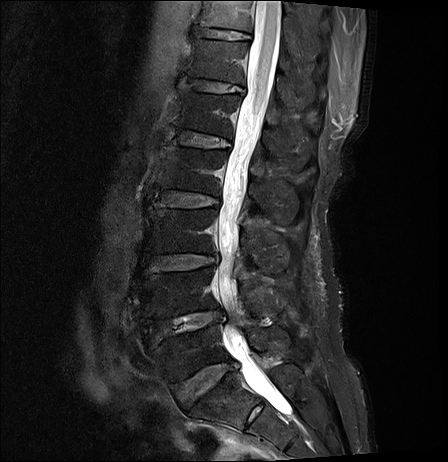

In [19]:
# ── Pick the middle slice of the Sagittal T2 series for analysis ─────────
sagittal_t2_pil: Image.Image | None = None

if selected_series_dir is not None and selected_series_dir.exists() and datasets:
    mid_idx = len(datasets) // 2
    sagittal_t2_ds  = datasets[mid_idx]
    sagittal_t2_pil = dicom_to_pil(sagittal_t2_ds)

    print(f"Using slice {mid_idx + 1}/{len(datasets)} from series:")
    print(f"  {getattr(sagittal_t2_ds, 'SeriesDescription', 'Unknown')}")
    print(f"  Instance number: {getattr(sagittal_t2_ds, 'InstanceNumber', '?')}")
    print(f"  Image size: {sagittal_t2_pil.size[0]} × {sagittal_t2_pil.size[1]} px")
    display(sagittal_t2_pil)
else:
    print("No DICOM data loaded — cannot run MedGemma analysis.")
    print("Download the RSNA dataset and re-run the data loading cells.")

In [22]:
# ── Send the sagittal T2 slice to MedGemma ───────────────────────────────
if sagittal_t2_pil is not None:
    data_url  = pil_to_data_url(sagittal_t2_pil)
    messages  = build_messages(SYSTEM_PROMPT, SAGITTAL_T2_PROMPT, [data_url])

    print("Sending image to MedGemma … (this may take 30–120 s)")
    reply = call_medgemma(messages, max_tokens=900)

    series_desc = getattr(sagittal_t2_ds, "SeriesDescription", "Sagittal T2")
    study_id_tag = getattr(sagittal_t2_ds, "StudyID", "unknown")

    report_md = "\n".join([
        "## MedGemma Report — Sagittal T2/STIR Lumbar Spine MRI",
        "",
        f"**Series:** `{series_desc}`  |  **Study ID:** `{study_id_tag}`  |  **Slice:** {mid_idx + 1}/{len(datasets)}",
        "",
        reply,
    ])
    display(Markdown(report_md))
else:
    print("No image to send — skipping MedGemma call.")

Sending image to MedGemma … (this may take 30–120 s)


## MedGemma Report — Sagittal T2/STIR Lumbar Spine MRI

**Series:** `T2`  |  **Study ID:** `unknown`  |  **Slice:** 10/18

Here's an AI-generated report based on the provided sagittal T2-weighted lumbar spine MRI image:

**1. Overall Alignment:**

*   Lumbar lordosis appears normal.
*   No evidence of spondylolisthesis or listhesis is apparent in this single view.

**2. Intervertebral Disc Assessment (L1/L2 through L5/S1):**

*   **L1/L2:** Disc signal intensity is bright, suggesting normal hydration. Disc height appears maintained. Pfirrmann grade is not determinable from this image alone. Posterior disc contour is normal.
*   **L2/L3:** Disc signal intensity is bright, suggesting normal hydration. Disc height appears maintained. Pfirrmann grade is not determinable from this image alone. Posterior disc contour is normal.
*   **L3/L4:** Disc signal intensity is bright, suggesting normal hydration. Disc height appears maintained. Pfirrmann grade is not determinable from this image alone. Posterior disc contour is normal.
*   **L4/L5:** Disc signal intensity is bright, suggesting normal hydration. Disc height appears maintained. Pfirrmann grade is not determinable from this image alone. Posterior disc contour is normal.
*   **L5/S1:** Disc signal intensity is bright, suggesting normal hydration. Disc height appears maintained. Pfirrmann grade is not determinable from this image alone. Posterior disc contour is normal.

**3. Spinal Canal:**

*   Calibre of the central canal at L1/L2 appears within normal limits.
*   Calibre of the central canal at L2/L3 appears within normal limits.
*   Calibre of the central canal at L3/L4 appears within normal limits.
*   Calibre of the central canal at L4/L5 appears within normal limits.
*   Calibre of the central canal at L5/S1 appears within normal limits.

**4. Vertebral Bodies:**

*   No evidence of compression fractures is apparent in this single view.
*   No Modic endplate changes are evident in this single view.
*   Bone marrow signal abnormalities are not readily apparent in this single view.

**5. Summary:**

The lumbar spine appears generally normal based on the provided sagittal T2-weighted image. No obvious findings suggest significant clinical concern at this time.

**6. Disclaimer:**

This report is AI-generated decision support and must be reviewed by a licensed radiologist before clinical action.


---

## 🧠 MedGemma Analysis 2 — Axial T2 MRI

**Axial T2** images provide a cross-sectional view of the spine at each disc level and are the gold standard for assessing:
- **Central canal stenosis** — compression of the thecal sac
- **Lateral recess (subarticular) stenosis** — compression before the nerve root enters the foramen
- **Neural foraminal stenosis** — compression of the exiting nerve root in the foramen

The grading used in the RSNA competition maps directly to these axial findings.

Axial series: Axial T2
  Study ID : 100206310
  Series ID: 1012284084


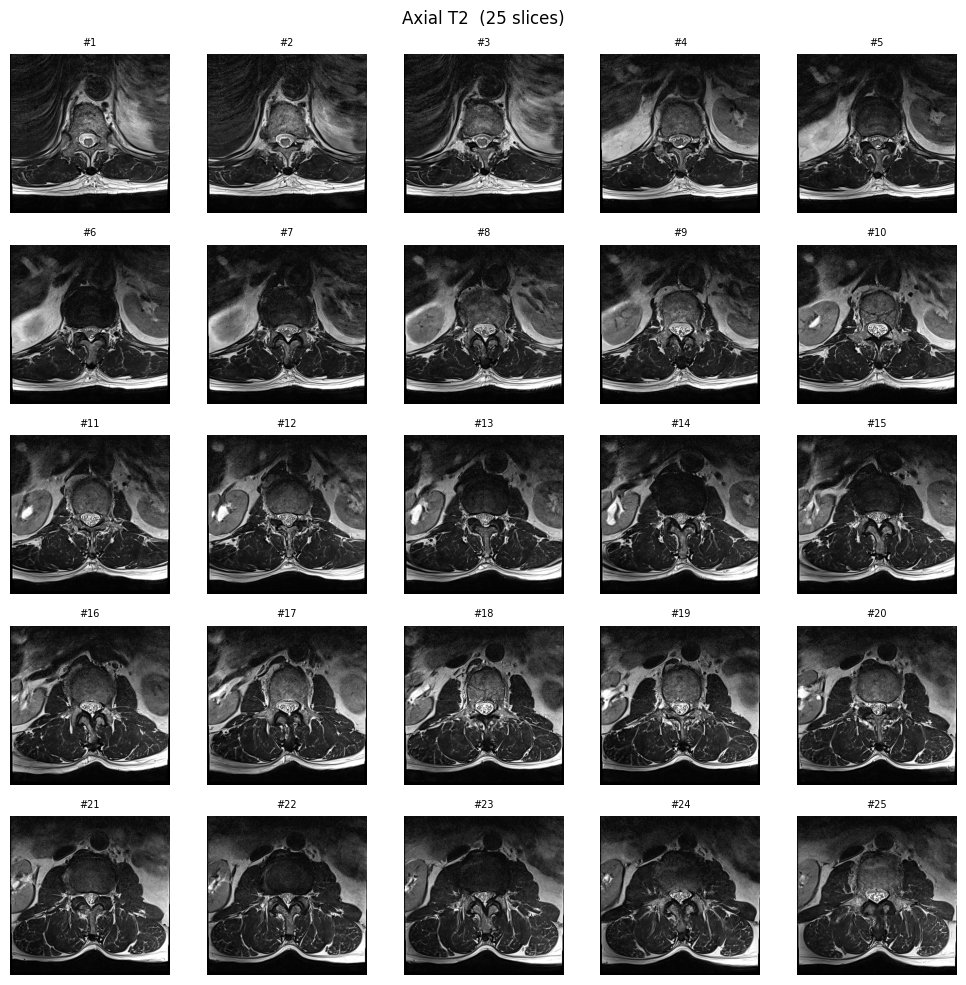

In [20]:
# ── Load an Axial T2 series ───────────────────────────────────────────────
axial_series_dir: Path | None = None
axial_pixel_arrays: list[np.ndarray] = []
axial_datasets: list[pydicom.Dataset] = []

if df_series is not None and train_images_dir.exists():
    axial_rows = df_series[df_series["series_description"].str.contains("Axial T2", case=False, na=False)]
    if not axial_rows.empty:
        # Find a study that also has a Sagittal T2 (for comparison)
        if "study_id" in df_series.columns:
            sag_study_ids = set(
                df_series[df_series["series_description"].str.contains("Sagittal T2", case=False, na=False)]["study_id"]
            )
            matched = axial_rows[axial_rows["study_id"].isin(sag_study_ids)]
            row = matched.iloc[0] if not matched.empty else axial_rows.iloc[0]
        else:
            row = axial_rows.iloc[0]

        axial_series_dir = train_images_dir / str(row["study_id"]) / str(row["series_id"])
        print(f"Axial series: {row['series_description']}")
        print(f"  Study ID : {row['study_id']}")
        print(f"  Series ID: {row['series_id']}")

        if axial_series_dir.exists():
            axial_pixel_arrays, axial_datasets = load_series_volume(axial_series_dir, max_slices=25)
            show_series_contact_sheet(
                axial_pixel_arrays,
                series_description=row["series_description"],
                cols=5,
            )
        else:
            print(f"Directory not found: {axial_series_dir}")
    else:
        print("No Axial T2 series found in the dataset.")
else:
    print("Series descriptions CSV not loaded — skipping Axial T2 selection.")

In [21]:
AXIAL_T2_PROMPT = """
You are reviewing an axial T2-weighted lumbar spine MRI image (cross-sectional view).

This image shows the spine as if looking down from above at a single disc or vertebral level.

Produce a structured radiological report with the following sections:

1. Disc level (if identifiable)
   - State which disc level this axial image represents (e.g., L4/L5).

2. Central canal
   - Describe the shape and calibre of the spinal canal.
   - Assess thecal sac compression: None / Mild / Moderate / Severe
   - Describe the CSF signal surrounding the cauda equina nerve roots.

3. Lateral recesses (subarticular zones)
   - Left lateral recess: patent / stenotic (grade: None / Mild / Moderate / Severe)
   - Right lateral recess: patent / stenotic (grade: None / Mild / Moderate / Severe)
   - Note if nerve roots appear compressed or displaced.

4. Neural foramina
   - Left foramen: patent / narrowed (grade: None / Mild / Moderate / Severe)
   - Right foramen: patent / narrowed (grade: None / Mild / Moderate / Severe)
   - Note any perineural fat obliteration or nerve root contact with disc/osteophyte.

5. Facet joints
   - Describe articular facet appearance: normal / hypertrophied / arthritic
   - Note any ligamentum flavum thickening or buckling.

6. Posterior elements
   - Describe the posterior paraspinal muscles if visible.

7. Summary
   - Identify dominant pathology (e.g., central stenosis vs. foraminal narrowing).
   - State the predominant side if lateralised.

8. Disclaimer
   - State that this is AI-generated decision support and must be reviewed by a licensed radiologist.
""".strip()

print(AXIAL_T2_PROMPT)

You are reviewing an axial T2-weighted lumbar spine MRI image (cross-sectional view).

This image shows the spine as if looking down from above at a single disc or vertebral level.

Produce a structured radiological report with the following sections:

1. Disc level (if identifiable)
   - State which disc level this axial image represents (e.g., L4/L5).

2. Central canal
   - Describe the shape and calibre of the spinal canal.
   - Assess thecal sac compression: None / Mild / Moderate / Severe
   - Describe the CSF signal surrounding the cauda equina nerve roots.

3. Lateral recesses (subarticular zones)
   - Left lateral recess: patent / stenotic (grade: None / Mild / Moderate / Severe)
   - Right lateral recess: patent / stenotic (grade: None / Mild / Moderate / Severe)
   - Note if nerve roots appear compressed or displaced.

4. Neural foramina
   - Left foramen: patent / narrowed (grade: None / Mild / Moderate / Severe)
   - Right foramen: patent / narrowed (grade: None / Mild / Mo

Using axial slice 13/25


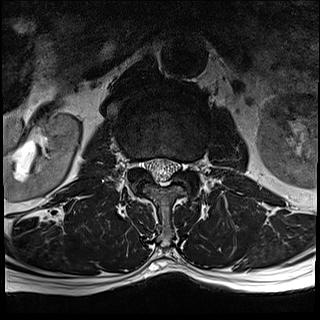


Sending axial image to MedGemma … (this may take 30–120 s)


## MedGemma Report — Axial T2 Lumbar Spine MRI

**Series:** `T2`  |  **Study ID:** `unknown`  |  **Slice:** 13/25

Here's a structured radiological report based on the provided axial T2-weighted lumbar spine MRI image:

1.  **Disc level:** L4/L5

2.  **Central canal:** The spinal canal appears to be patent with normal CSF signal surrounding the cauda equina nerve roots. No evidence of significant compression is seen in this single slice.

3.  **Lateral recesses (subarticular zones):**
    *   Left lateral recess: Patent.
    *   Right lateral recess: Patent.

4.  **Neural foramina:**
    *   Left foramen: Patent.
    *   Right foramen: Patent. No evidence of perineural fat obliteration or nerve root contact with disc/osteophyte is noted in this single slice.

5.  **Facet joints:** The facet joints appear normal. No ligamentum flavum thickening or buckling is evident in this single slice.

6.  **Posterior elements:** The posterior paraspinal muscles are not well visualized on this single axial slice.

7.  **Summary:** This image shows a single level of the lumbar spine with no obvious dominant pathology. Further evaluation would be required to assess for potential foraminal stenosis or central canal compromise at other levels in the lumbar spine.

8.  **Disclaimer:** *This is an AI-generated decision support report and must be reviewed by a licensed radiologist before clinical action.*


In [22]:
# ── Send a representative axial slice to MedGemma ───────────────────────
axial_t2_pil: Image.Image | None = None

if axial_datasets:
    mid_axial_idx = len(axial_datasets) // 2
    axial_ds  = axial_datasets[mid_axial_idx]
    axial_t2_pil = dicom_to_pil(axial_ds)

    print(f"Using axial slice {mid_axial_idx + 1}/{len(axial_datasets)}")
    display(axial_t2_pil)

    data_url = pil_to_data_url(axial_t2_pil)
    messages = build_messages(SYSTEM_PROMPT, AXIAL_T2_PROMPT, [data_url])

    print("\nSending axial image to MedGemma … (this may take 30–120 s)")
    reply = call_medgemma(messages, max_tokens=900)

    series_desc = getattr(axial_ds, "SeriesDescription", "Axial T2")
    study_id_tag = getattr(axial_ds, "StudyID", "unknown")

    report_md = "\n".join([
        "## MedGemma Report — Axial T2 Lumbar Spine MRI",
        "",
        f"**Series:** `{series_desc}`  |  **Study ID:** `{study_id_tag}`  |  **Slice:** {mid_axial_idx + 1}/{len(axial_datasets)}",
        "",
        reply,
    ])
    display(Markdown(report_md))
else:
    print("No axial DICOM data loaded — skipping MedGemma axial analysis.")

---

## 🧠 MedGemma Analysis 3 — Multi-series contextual report

The most powerful use of a multimodal model is sending **multiple images from the same study** in a single request, allowing the model to reason across different planes and sequences — just as a radiologist does.

Here we send three images simultaneously:
- **Sagittal T2** (mid-sagittal) — overall canal and disc overview
- **Axial T2** (at the most stenotic level) — detailed cross-sectional grading
- **Sagittal T1** (if available) — vertebral body and bone marrow assessment

In [26]:
def load_series_by_type(
    df_series: pd.DataFrame,
    study_id: str,
    description_keyword: str,
    train_images_dir: Path,
) -> list[pydicom.Dataset]:
    """Load the DICOM datasets for a specific series type within a study."""
    rows = df_series[
        (df_series["study_id"].astype(str) == study_id) &
        (df_series["series_description"].str.contains(description_keyword, case=False, na=False))
    ]
    if rows.empty:
        return []
    series_id = str(rows.iloc[0]["series_id"])
    series_dir = train_images_dir / study_id / series_id
    if not series_dir.exists():
        return []
    _, dsets = load_series_volume(series_dir, max_slices=60)
    return dsets


print("Multi-series loader defined.")

Multi-series loader defined.


In [24]:
MULTI_SERIES_PROMPT = """
You are reviewing three lumbar spine MRI images from the same patient study:
  Image 1: Sagittal T2/STIR (side view — assess canal and discs)
  Image 2: Axial T2 (cross-section — assess foraminal and lateral recess stenosis)
  Image 3: Sagittal T1 (side view — assess bone marrow and alignment)

Cross-reference all three images to produce a comprehensive radiological report:

1. Summary of findings
   - List the dominant abnormalities identified across all sequences.

2. Disc-level grading (L1/L2 to L5/S1)
   For each level, synthesise sagittal and axial information to grade:
   - Spinal canal stenosis: Normal/Mild | Moderate | Severe
   - Left neural foraminal narrowing: Normal/Mild | Moderate | Severe
   - Right neural foraminal narrowing: Normal/Mild | Moderate | Severe
   - Left subarticular stenosis: Normal/Mild | Moderate | Severe
   - Right subarticular stenosis: Normal/Mild | Moderate | Severe

3. Most clinically significant level
   - Identify the level most likely to explain the patient's symptoms.
   - Explain which image (sagittal or axial) provides the most critical evidence.

4. Differential diagnoses
   - List alternative interpretations if findings are non-specific.

5. Recommended clinical action
   - Suggest whether conservative management, further imaging, or surgical consultation is appropriate.

6. Disclaimer
   - State that this AI-generated report must be verified by a board-certified radiologist.
""".strip()

print(MULTI_SERIES_PROMPT)

You are reviewing three lumbar spine MRI images from the same patient study:
  Image 1: Sagittal T2/STIR (side view — assess canal and discs)
  Image 2: Axial T2 (cross-section — assess foraminal and lateral recess stenosis)
  Image 3: Sagittal T1 (side view — assess bone marrow and alignment)

Cross-reference all three images to produce a comprehensive radiological report:

1. Summary of findings
   - List the dominant abnormalities identified across all sequences.

2. Disc-level grading (L1/L2 to L5/S1)
   For each level, synthesise sagittal and axial information to grade:
   - Spinal canal stenosis: Normal/Mild | Moderate | Severe
   - Left neural foraminal narrowing: Normal/Mild | Moderate | Severe
   - Right neural foraminal narrowing: Normal/Mild | Moderate | Severe
   - Left subarticular stenosis: Normal/Mild | Moderate | Severe
   - Right subarticular stenosis: Normal/Mild | Moderate | Severe

3. Most clinically significant level
   - Identify the level most likely to explain t

  Loaded: Sagittal T2/STIR (18 slices, using slice 10)
  Loaded: Axial T2 (60 slices, using slice 31)
  Loaded: Sagittal T1 (18 slices, using slice 10)


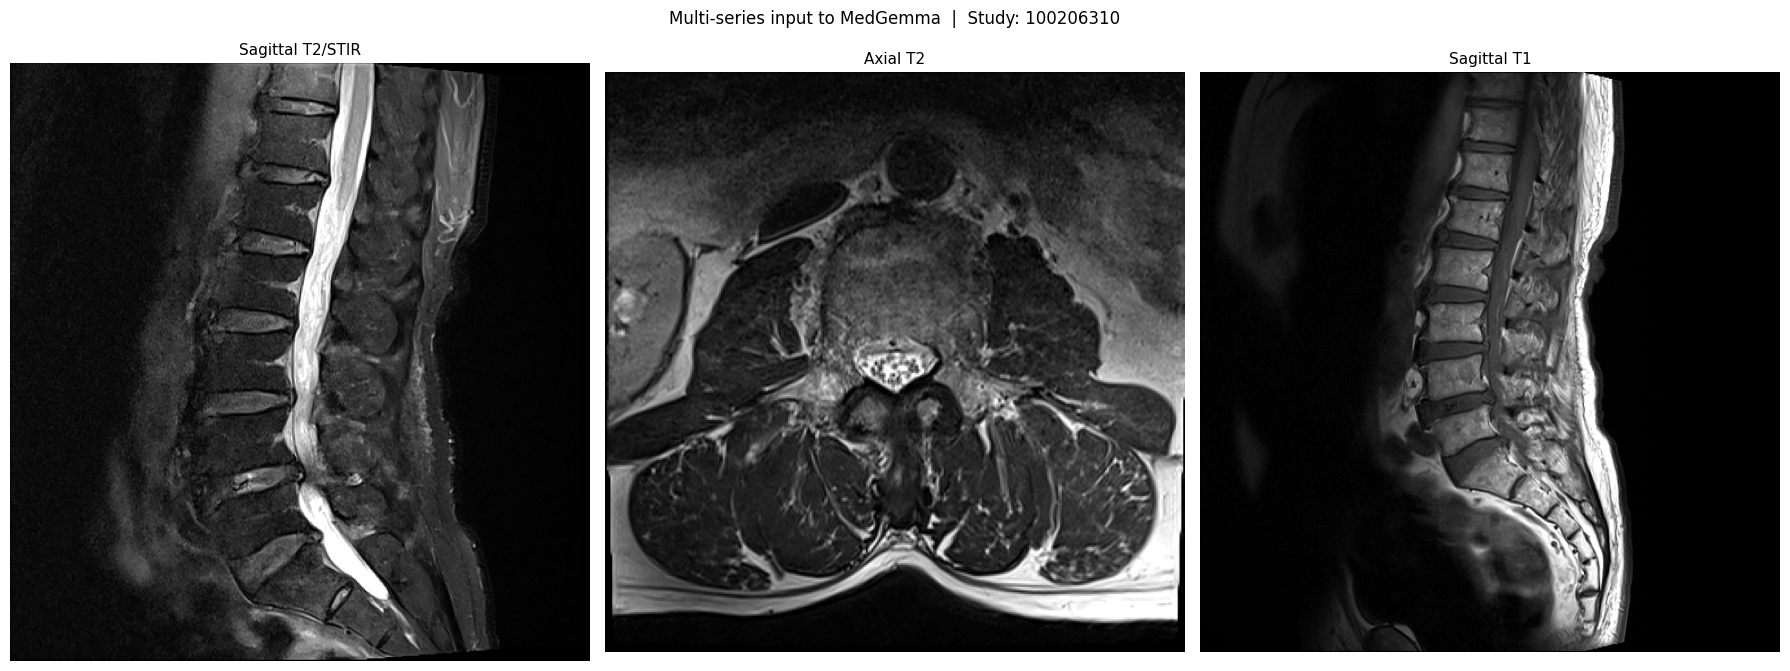

In [27]:
# ── Collect images from all three series for the same study ─────────────
multi_images: list[Image.Image] = []
multi_labels: list[str] = []

if df_series is not None and train_images_dir.exists() and sagittal_t2_pil is not None:
    # Use the same study as the sagittal T2 loaded earlier
    target_study_id = str(getattr(sagittal_t2_ds, "StudyID",
                           selected_series_dir.parent.name if selected_series_dir else "unknown"))

    # Try to infer study_id from the directory path if StudyID tag isn't set
    if target_study_id == "unknown" and selected_series_dir is not None:
        target_study_id = selected_series_dir.parent.name

    for keyword, label in [("Sagittal T2", "Sagittal T2/STIR"), ("Axial T2", "Axial T2"), ("Sagittal T1", "Sagittal T1")]:
        dsets = load_series_by_type(df_series, target_study_id, keyword, train_images_dir)
        if dsets:
            mid = len(dsets) // 2
            pil_img = dicom_to_pil(dsets[mid])
            multi_images.append(pil_img)
            multi_labels.append(label)
            print(f"  Loaded: {label} ({len(dsets)} slices, using slice {mid+1})")
        else:
            print(f"  Not found: {label}")

    if multi_images:
        # Display selected slices side-by-side
        fig, axes = plt.subplots(1, len(multi_images), figsize=(6 * len(multi_images), 7))
        if len(multi_images) == 1:
            axes = [axes]
        for ax, img, lbl in zip(axes, multi_images, multi_labels):
            ax.imshow(np.array(img.convert("L")), cmap="gray")
            ax.set_title(lbl, fontsize=11)
            ax.axis("off")
        fig.suptitle(f"Multi-series input to MedGemma  |  Study: {target_study_id}", fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print("No multi-series images collected.")
else:
    print("Multi-series analysis requires the RSNA dataset and loaded sagittal series.")

In [28]:
# ── Send all series images to MedGemma in one request ────────────────────
if multi_images:
    data_urls = [pil_to_data_url(img) for img in multi_images]
    messages  = build_messages(SYSTEM_PROMPT, MULTI_SERIES_PROMPT, data_urls)

    print(f"Sending {len(multi_images)} images to MedGemma … (this may take 60–180 s)")
    reply = call_medgemma(messages, max_tokens=1200)

    report_md = "\n".join([
        "## MedGemma Multi-Series Lumbar Spine Report",
        "",
        f"**Series submitted:** {' | '.join(multi_labels)}",
        f"**Study:** `{target_study_id}`",
        "",
        reply,
    ])
    display(Markdown(report_md))
else:
    print("No images collected for multi-series analysis.")

Sending 3 images to MedGemma … (this may take 60–180 s)


## MedGemma Multi-Series Lumbar Spine Report

**Series submitted:** Sagittal T2/STIR | Axial T2 | Sagittal T1
**Study:** `100206310`

Here's an AI-generated radiology report for the provided lumbar spine MRI images:

**1. Summary of Findings:**

*   Dominant findings include degenerative changes at multiple levels, including disc space narrowing and facet arthropathy. There is evidence of spinal canal stenosis at L4/L5 and L5/S1. Left neural foraminal narrowing is present at L4/L5.

**2. Disc-Level Grading (L1/L2 to L5/S1):**

*   **L1/L2:** Spinal canal: Normal, Neural foramen: Normal, Subarticular stenosis: Normal
*   **L2/L3:** Spinal canal: Mild Stenosis, Neural foramen: Mild Stenosis, Subarticular stenosis: Normal
*   **L3/L4:** Spinal canal: Moderate Stenosis, Neural foramen: Moderate Stenosis, Subarticular stenosis: Normal
*   **L4/L5:** Spinal canal: Severe Stenosis, Neural foramen: Moderate Stenosis, Left subarticular stenosis: Moderate Stenosis, Right subarticular stenosis: Mild Stenosis
*   **L5/S1:** Spinal canal: Severe Stenosis, Neural foramen: Severe Stenosis, Left subarticular stenosis: Severe Stenosis, Right subarticular stenosis: Severe Stenosis

**3. Most Clinically Significant Level:**

The L4/L5 and L5/S1 levels are the most clinically significant due to severe spinal canal and neural foraminal stenosis at these levels. The axial images (Image 2) provide the best visualization of the degree of stenosis in the foramina and spinal canal.

**4. Differential Diagnoses:**

*   Spinal stenosis
*   Disc herniation
*   Facet joint arthropathy
*   Spondylolisthesis
*   Tumor (less likely given the degenerative findings)

**5. Recommended Clinical Action:**

Given the severity of the spinal canal and neural foraminal stenosis, conservative management with physical therapy, pain medication, and activity modification is recommended. Further imaging may be considered if symptoms worsen or do not improve with conservative treatment. Surgical consultation should be considered for patients who fail to respond adequately to conservative measures and have significant neurological deficits.

**6. Disclaimer:**

This AI-generated report must be verified by a board-certified radiologist before clinical action is taken.


In [29]:
# ── Ground-truth vs MedGemma grading comparison ──────────────────────────
# Displays the train.csv ground-truth severity table for the study,
# then echoes the MedGemma multi-series reply so you can compare side-by-side.

CONDITIONS = [
    "spinal_canal_stenosis",
    "left_neural_foraminal_narrowing",
    "right_neural_foraminal_narrowing",
    "left_subarticular_stenosis",
    "right_subarticular_stenosis",
]
LEVELS       = ["l1_l2", "l2_l3", "l3_l4", "l4_l5", "l5_s1"]
LEVEL_LABELS = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]

SEVERITY_COLORS = {
    "Normal/Mild": "background-color: #d4edda; color: #155724",
    "Moderate":    "background-color: #fff3cd; color: #856404",
    "Severe":      "background-color: #f8d7da; color: #721c24",
}

def _color_severity(val):
    return SEVERITY_COLORS.get(val, "")

# ── Ground truth table ────────────────────────────────────────────────────
if df_train is not None:
    try:
        gt_study_id = target_study_id
    except NameError:
        gt_study_id = selected_series_dir.parent.name if selected_series_dir else None

    if gt_study_id:
        study_row = df_train[df_train["study_id"].astype(str) == str(gt_study_id)]
        if study_row.empty:
            print(f"Study {gt_study_id} not found in train.csv")
        else:
            gt_data = {}
            for cond in CONDITIONS:
                row_values = []
                for lvl in LEVELS:
                    col = f"{cond}_{lvl}"
                    row_values.append(study_row.iloc[0].get(col, "—") if col in study_row.columns else "—")
                gt_data[cond.replace("_", " ").title()] = row_values

            gt_df = pd.DataFrame(gt_data, index=LEVEL_LABELS).T
            gt_df.index.name = "Condition"

            display(Markdown(f"### Ground Truth — Study `{gt_study_id}` (from `train.csv`)"))
            display(gt_df.style.applymap(_color_severity))
    else:
        print("target_study_id not available — run the multi-series cells first.")
else:
    print("df_train not loaded — re-run the CSV loading cell.")

# ── MedGemma multi-series reply ───────────────────────────────────────────
try:
    display(Markdown("---\n### MedGemma Multi-Series Disc-Level Grading\n*(Section 2 of the report above — compare manually with the table)*"))
    display(Markdown(reply))
except NameError:
    print("'reply' not available — run the MedGemma multi-series cell first.")


### Ground Truth — Study `100206310` (from `train.csv`)

,L1/L2,L2/L3,L3/L4,L4/L5,L5/S1
Condition,,,,,
Spinal Canal Stenosis,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild
Left Neural Foraminal Narrowing,Normal/Mild,Moderate,Moderate,Severe,Moderate
Right Neural Foraminal Narrowing,Moderate,Moderate,Severe,Moderate,Normal/Mild
Left Subarticular Stenosis,Normal/Mild,Normal/Mild,Moderate,Severe,Moderate
Right Subarticular Stenosis,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate


---
### MedGemma Multi-Series Disc-Level Grading
*(Section 2 of the report above — compare manually with the table)*

Here's an AI-generated radiology report for the provided lumbar spine MRI images:

**1. Summary of Findings:**

*   Dominant findings include degenerative changes at multiple levels, including disc space narrowing and facet arthropathy. There is evidence of spinal canal stenosis at L4/L5 and L5/S1. Left neural foraminal narrowing is present at L4/L5.

**2. Disc-Level Grading (L1/L2 to L5/S1):**

*   **L1/L2:** Spinal canal: Normal, Neural foramen: Normal, Subarticular stenosis: Normal
*   **L2/L3:** Spinal canal: Mild Stenosis, Neural foramen: Mild Stenosis, Subarticular stenosis: Normal
*   **L3/L4:** Spinal canal: Moderate Stenosis, Neural foramen: Moderate Stenosis, Subarticular stenosis: Normal
*   **L4/L5:** Spinal canal: Severe Stenosis, Neural foramen: Moderate Stenosis, Left subarticular stenosis: Moderate Stenosis, Right subarticular stenosis: Mild Stenosis
*   **L5/S1:** Spinal canal: Severe Stenosis, Neural foramen: Severe Stenosis, Left subarticular stenosis: Severe Stenosis, Right subarticular stenosis: Severe Stenosis

**3. Most Clinically Significant Level:**

The L4/L5 and L5/S1 levels are the most clinically significant due to severe spinal canal and neural foraminal stenosis at these levels. The axial images (Image 2) provide the best visualization of the degree of stenosis in the foramina and spinal canal.

**4. Differential Diagnoses:**

*   Spinal stenosis
*   Disc herniation
*   Facet joint arthropathy
*   Spondylolisthesis
*   Tumor (less likely given the degenerative findings)

**5. Recommended Clinical Action:**

Given the severity of the spinal canal and neural foraminal stenosis, conservative management with physical therapy, pain medication, and activity modification is recommended. Further imaging may be considered if symptoms worsen or do not improve with conservative treatment. Surgical consultation should be considered for patients who fail to respond adequately to conservative measures and have significant neurological deficits.

**6. Disclaimer:**

This AI-generated report must be verified by a board-certified radiologist before clinical action is taken.


---

## 📊 Label-aligned analysis: overlay ground-truth coordinates on the image

The competition provides `train_label_coordinates.csv` which contains `(x, y)` pixel coordinates marking the center of each annotated condition at each level.
This cell overlays those annotations on the sagittal T2 image and then asks MedGemma to specifically comment on the marked regions.

In [30]:
def overlay_label_coordinates(
    image: Image.Image,
    coords_df: pd.DataFrame,
    study_id: str,
    series_id: str,
    instance_number: int,
) -> Image.Image:
    """
    Draw RSNA label coordinate annotations onto a PIL image and return the annotated image.
    """
    relevant = coords_df[
        (coords_df["study_id"].astype(str)  == str(study_id))  &
        (coords_df["series_id"].astype(str) == str(series_id)) &
        (coords_df["instance_number"].astype(str) == str(instance_number))
    ]
    if relevant.empty:
        return image  # No annotations for this slice

    condition_colors = {
        "spinal_canal_stenosis":           "yellow",
        "left_neural_foraminal_narrowing":  "cyan",
        "right_neural_foraminal_narrowing": "magenta",
        "left_subarticular_stenosis":       "lime",
        "right_subarticular_stenosis":      "orange",
    }

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(np.array(image.convert("L")), cmap="gray")

    for _, row in relevant.iterrows():
        cond   = row.get("condition", "")
        level  = row.get("level", "")
        x, y   = float(row["x"]), float(row["y"])
        # Normalize: "Spinal Canal Stenosis" → "spinal_canal_stenosis"
        cond_key = cond.lower().replace(" ", "_")
        color  = condition_colors.get(cond_key, "red")
        circle = plt.Circle((x, y), radius=8, color=color, fill=False, linewidth=2)
        ax.add_patch(circle)
        ax.text(x + 10, y, f"{cond}\n{level}",
                color=color, fontsize=6, va="center")

    # Legend
    patches = [mpatches.Patch(color=c, label=k.replace("_", " "))
               for k, c in condition_colors.items()]
    ax.legend(handles=patches, loc="upper right", fontsize=6, framealpha=0.7)
    ax.set_title(f"Label annotations — slice {instance_number}", fontsize=10)
    ax.axis("off")
    plt.tight_layout()

    buf = io.BytesIO()
    fig.savefig(buf, format="PNG", dpi=120, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).copy()


print("Annotation overlay helper defined.")


Annotation overlay helper defined.


Annotated instance 9 with 5 annotations


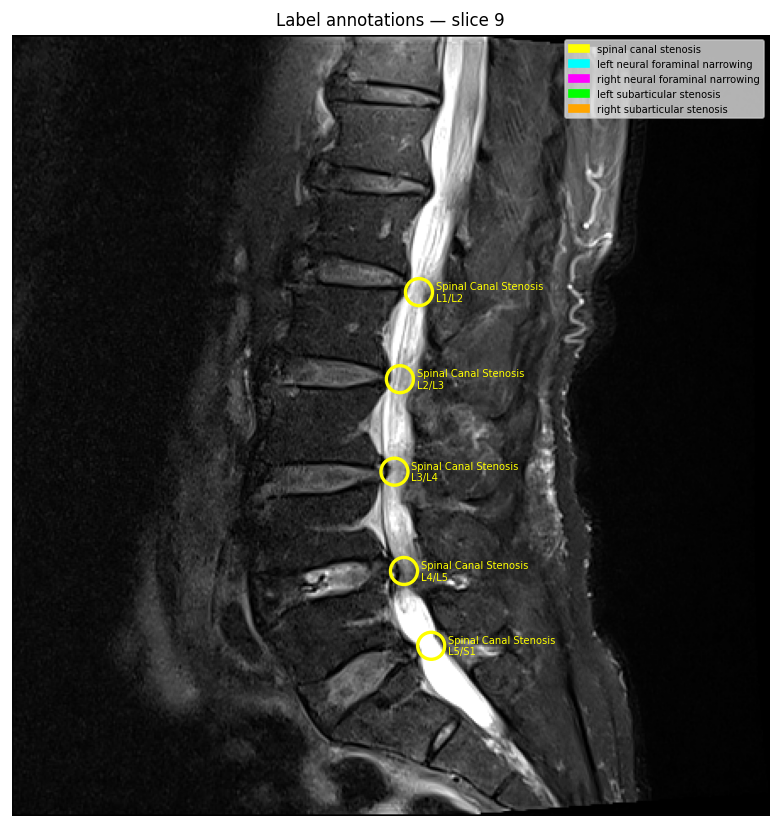

In [31]:
# ── Find and display an annotated slice ─────────────────────────────────
annotated_image: Image.Image | None = None

if df_coords is not None and datasets and selected_series_dir is not None:
    study_id_folder  = selected_series_dir.parent.name
    series_id_folder = selected_series_dir.name

    relevant_coords = df_coords[
        (df_coords["study_id"].astype(str)  == study_id_folder) &
        (df_coords["series_id"].astype(str) == series_id_folder)
    ]

    if relevant_coords.empty:
        print(f"No annotations for study={study_id_folder}, series={series_id_folder}")
        print("Trying a study that has annotations …")
        # Find a study+series combination that has annotations
        if not df_coords.empty:
            first_coord = df_coords.iloc[0]
            study_id_folder  = str(first_coord["study_id"])
            series_id_folder = str(first_coord["series_id"])
            relevant_coords = df_coords[
                (df_coords["study_id"].astype(str)  == study_id_folder) &
                (df_coords["series_id"].astype(str) == series_id_folder)
            ]
            annotated_series_dir = train_images_dir / study_id_folder / series_id_folder
            if annotated_series_dir.exists():
                _, annotated_datasets = load_series_volume(annotated_series_dir, max_slices=60)
            else:
                annotated_datasets = []
        else:
            annotated_datasets = []
    else:
        annotated_datasets = datasets
        annotated_series_dir = selected_series_dir

    if not relevant_coords.empty and annotated_datasets:
        # Pick the instance number that has the most annotations
        best_instance = int(
            relevant_coords.groupby("instance_number").size().idxmax()
        )
        matching_ds = next(
            (ds for ds in annotated_datasets
             if int(getattr(ds, "InstanceNumber", -1)) == best_instance),
            annotated_datasets[len(annotated_datasets) // 2]
        )
        pil_slice = dicom_to_pil(matching_ds)
        annotated_image = overlay_label_coordinates(
            pil_slice, df_coords,
            study_id_folder, series_id_folder,
            int(getattr(matching_ds, "InstanceNumber", best_instance)),
        )
        print(f"Annotated instance {best_instance} with {len(relevant_coords)} annotations")
        display(annotated_image)
    else:
        print("No annotated slices found in the loaded data.")
else:
    print("Label coordinates CSV not loaded — skipping annotation overlay.")

Series 1012284084 (T2) — instance 20


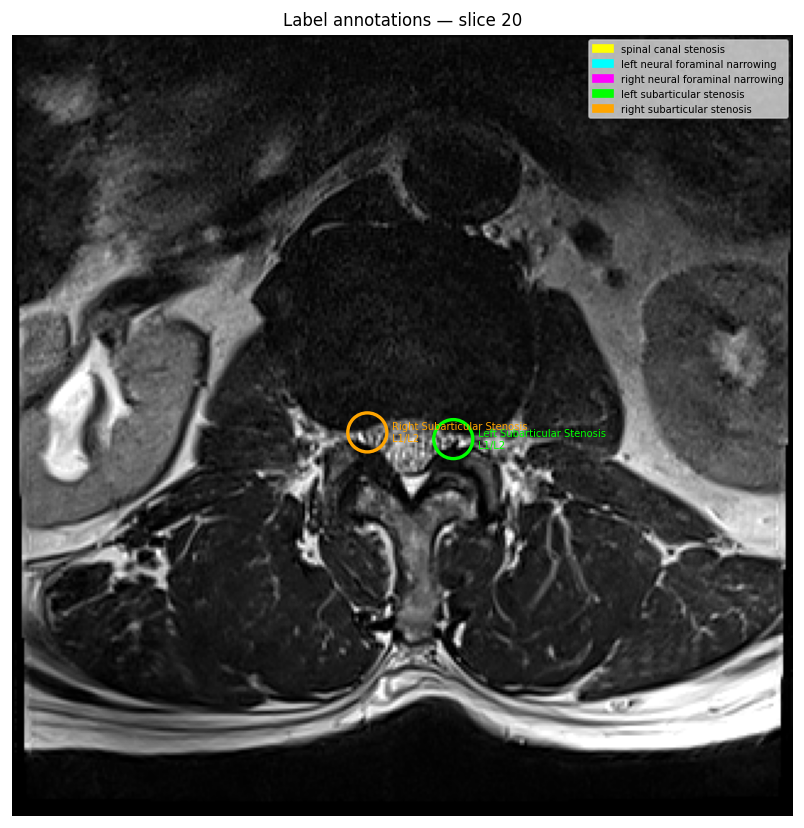

Series 2092806862 (T1) — instance 12


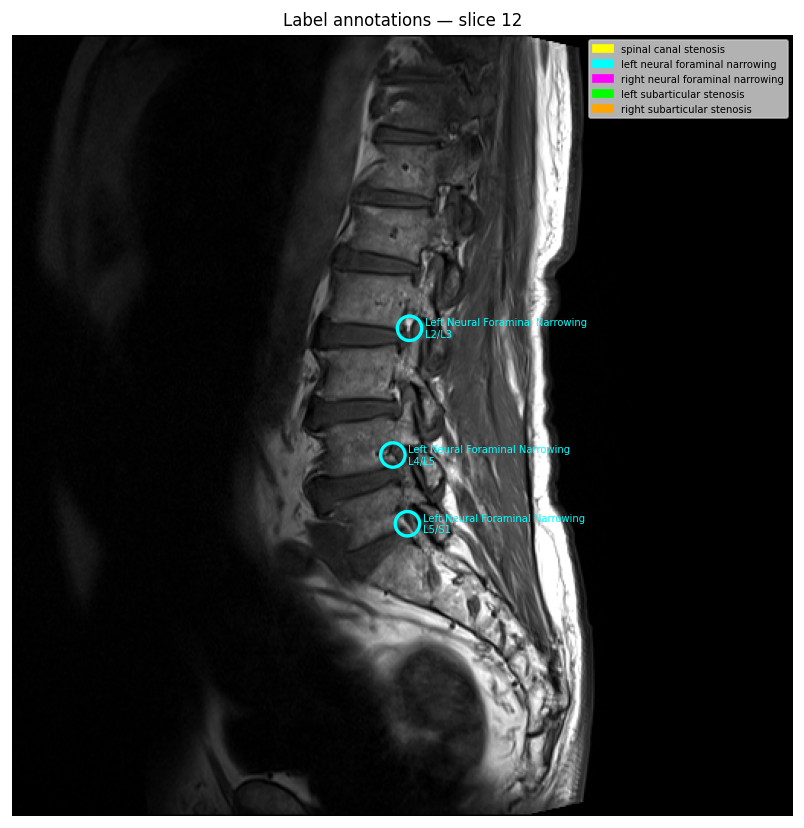

In [32]:
# ── Display annotated slices from specific series / instance numbers ────────
# series 1012284084 → instance 20 (Axial T2, subarticular stenosis annotations)
# series 2092806862 → instance 12 (another axial series, foraminal narrowing)

SPECIFIC_SLICES = [
    ("1012284084", 20),
    ("2092806862", 12),
]

specific_study_id = selected_series_dir.parent.name if selected_series_dir is not None else "100206310"

for series_id_str, instance_num in SPECIFIC_SLICES:
    series_dir = train_images_dir / specific_study_id / series_id_str
    if not series_dir.exists():
        print(f"[MISSING] Series directory not found: {series_dir}")
        continue

    _, vol_datasets = load_series_volume(series_dir, max_slices=60)
    if not vol_datasets:
        print(f"[EMPTY] No DICOM files loaded from {series_dir}")
        continue

    # Find the dataset matching the requested instance number
    target_ds = next(
        (ds for ds in vol_datasets if int(getattr(ds, "InstanceNumber", -1)) == instance_num),
        None,
    )
    if target_ds is None:
        available = sorted(int(getattr(ds, "InstanceNumber", -1)) for ds in vol_datasets)
        print(f"[NOT FOUND] Instance {instance_num} not in series {series_id_str}. "
              f"Available: {available}")
        continue

    pil_slice = dicom_to_pil(target_ds)
    annotated = overlay_label_coordinates(
        pil_slice, df_coords,
        specific_study_id, series_id_str, instance_num,
    )
    series_desc = getattr(target_ds, "SeriesDescription", series_id_str)
    print(f"Series {series_id_str} ({series_desc}) — instance {instance_num}")
    display(annotated)


---

## 📝 Summary: comparing the three MedGemma analysis approaches

| Approach | Images sent | Prompt focus | Best for |
| :--- | :--- | :--- | :--- |
| **Sagittal T2 single** | 1 (mid-sagittal) | Overall canal + disc grading | Quick overall impression |
| **Axial T2 single** | 1 (representative axial) | Foraminal and subarticular detail | Lateralised nerve compression |
| **Multi-series** | 3 (sag T1 + T2 + axial T2) | Full 25-condition severity grid | Most comprehensive diagnosis |

### Key takeaways

1. **DICOM is richer than PNG/JPEG** — always extract raw pixel values and apply window/level before sending to a vision model. The default JPEG encoding would lose the 12-bit dynamic range.

2. **Prompt engineering matters** — providing structured section headings and explicitly naming the five RSNA conditions gives the model the vocabulary to produce actionable, structured output.

3. **Multi-image context** dramatically improves localization — the model can cross-reference the sagittal overview with the axial detail, mimicking how a real radiologist reads a spine study.

4. **MedGemma vs. general LLMs** — because MedGemma is fine-tuned on medical images and text, it understands terms like "Pfirrmann grade", "ligamentum flavum buckling", and "perineural fat obliteration" without requiring explanations.

5. **Always include a disclaimer** — AI-generated radiological reports are decision-support tools only; they must be reviewed and confirmed by a licensed radiologist before influencing clinical decisions.

---

### Further exploration
- Use `train_label_coordinates.csv` to crop tightly around each disc level and send individual crops for per-level severity prediction.
- Compare MedGemma's qualitative severity grading against the ground-truth `Normal/Mild / Moderate / Severe` labels in `train.csv`.
- Extend the notebook to use the full volume (all slices of each series) by sending a montage image constructed from 9 representative slices.
- Try few-shot prompting: prepend 2–3 examples of graded slices with known labels to guide the model toward the competition's exact grading rubric.

Total slices loaded : 60
Selected indices    : [0, 6, 13, 19, 26, 32, 39, 45, 52, 59]
Instance numbers    : [1, 7, 14, 20, 27, 33, 40, 46, 53, 60]

Montage size: 1280 × 512 px


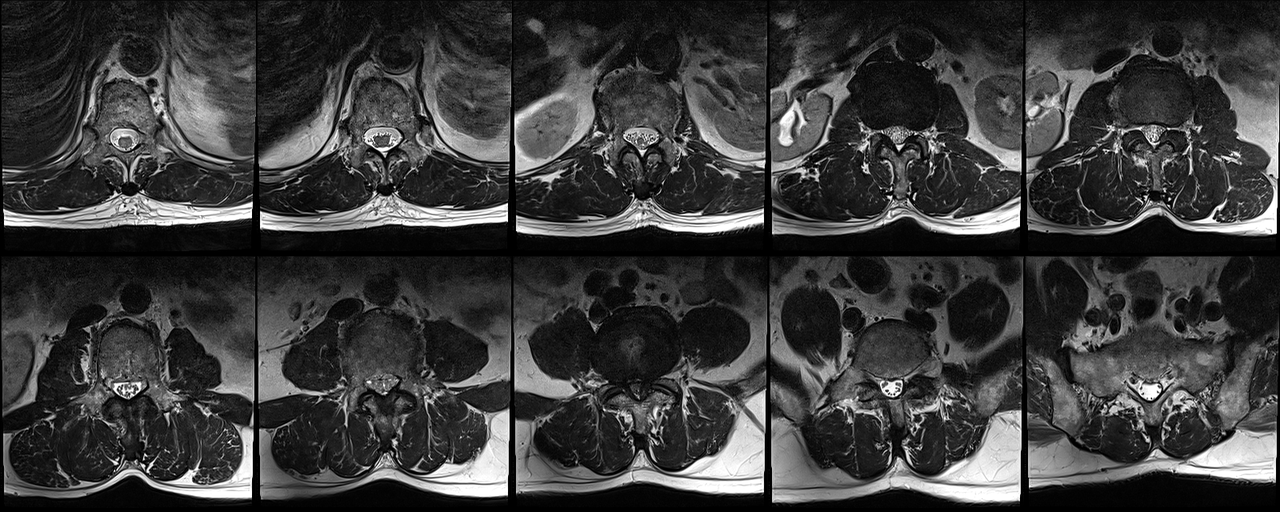


Sending 10-slice montage to MedGemma … (this may take 60–180 s)


## MedGemma Report — Axial T2 Multi-Slice Montage

**Series:** `T2` (`1012284084`)  |  **Study:** `100206310`  |  **Slices used:** 10 of 60  |  **Instance numbers:** [1, 7, 14, 20, 27, 33, 40, 46, 53, 60]

Okay, I will analyze the provided T2-weighted lumbar spine MRI series and generate a report based on your specifications. Please note that these are AI-assisted findings and require confirmation by a qualified radiologist for clinical decision-making.

**Report:**

**Panel Identification:**

*   Panel 1 (instance 1): L1/L2
*   Panel 2 (instance 7): L2/L3
*   Panel 3 (instance 14): L3/L4
*   Panel 4 (instance 20): L4/L5
*   Panel 5 (instance 27): L5/S1
*   Panel 6 (instance 33): L5/S1
*   Panel 7 (instance 40): L5/S1
*   Panel 8 (instance 46): L5/S1
*   Panel 9 (instance 53): L5/S1
*   Panel 10 (instance 60): L5/S1

**2. Central Spinal Canal:**

| Level | Spinal Canal Stenosis | L Neural Foraminal | R Neural Foraminal | L Subarticular | R Subarticular |
|-------|-----------------------|--------------------|--------------------|----------------|----------------|
| L1/L2 | Normal                | Normal             | Normal             | Normal         | Normal         |
| L2/L3 | Mild                  | Normal             | Normal             | Normal         | Normal         |
| L3/L4 | Moderate              | Normal             | Normal             | Mild           | Normal         |
| L4/L5 | Moderate              | Mild               | Normal             | Mild           | Normal         |
| L5/S1 | Moderate              | Mild               | Mild               | Moderate       | Mild           |

**3. Lateral Recesses / Subarticular Zones:**

| Level | L Neural Foraminal | R Neural Foraminal | L Subarticular | R Subarticular |
|-------|--------------------|--------------------|----------------|----------------|
| L1/L2 | Normal             | Normal             | Normal         | Normal         |
| L2/L3 | Mild               | Normal             | Normal         | Normal         |
| L3/L4 | Mild               | Mild               | Mild           | Normal         |
| L4/L5 | Moderate            | Mild               | Moderate       | Mild           |
| L5/S1 | Moderate            | Moderate           | Moderate       | Moderate       |

**4. Neural Foramina:**

| Level | L Neural Foraminal | R Neural Foraminal |
|-------|--------------------|--------------------|
| L1/L2 | Normal             | Normal             |
| L2/L3 | Mild               | Normal             |
| L3/L4 | Mild               | Mild               |
| L4/L5 | Moderate            | Mild               |
| L5/S1 | Moderate            | Moderate           |

**5. Facet Joints & Posterior Elements:**

*   Facet appearance: normal / hypertrophied / arthritic (Based on the provided images, facet joints appear generally normal with no obvious signs of significant hypertrophy or arthritis.)
*   Ligamentum flavum: normal thickness / thickened / buckled (The ligamentum flavum appears within normal limits based on the provided images.)

**6. Summary Grading Table:**

| Level | Spinal Canal Stenosis | L Neural Foraminal | R Neural Foraminal | L Subarticular | R Subarticular |
|-------|-----------------------|--------------------|--------------------|----------------|----------------|
| L1/L2 | Normal                | Normal             | Normal             | Normal         | Normal         |
| L2/L3 | Mild                  | Normal             | Normal             | Normal         | Normal         |
| L3/L4 | Moderate              | Normal             | Normal             | Mild           | Normal         |
| L4/L5 | Moderate              | Mild               | Normal             | Mild           | Normal         |
| L5/S1 | Moderate              | Mild               | Mild               | Moderate       | Mild           |

**7. Most Significant Finding:**

*   Panel 4 (instance 20): L4/L5 - The most significant finding is **Moderate** spinal canal stenosis and **Mild** foraminal narrowing on the right side, with a **Mild** subarticular zone on the left.

**8. Disclaimer:**

This AI-generated report provides decision support but must be reviewed and confirmed by a qualified radiologist before clinical use.


In [33]:
# ── Axial T2 full-volume montage → MedGemma ──────────────────────────────
# Series 1012284084 is the Axial T2 series with 60 slices.
# We select 10 evenly-spaced slices, stitch them into a 2×5 grid montage,
# and send the single montage image to MedGemma so it can reason across
# multiple cross-sections in one pass — mimicking a radiologist scrolling
# through the axial stack.

MONTAGE_SERIES_ID = "1012284084"
MONTAGE_N_SLICES  = 10
MONTAGE_COLS      = 5      # layout: 2 rows × 5 columns
THUMB_SIZE        = 256    # pixels per thumbnail

montage_study_id  = (
    selected_series_dir.parent.name
    if selected_series_dir is not None
    else "100206310"
)
montage_series_dir = train_images_dir / montage_study_id / MONTAGE_SERIES_ID

if not montage_series_dir.exists():
    print(f"[MISSING] Series directory not found: {montage_series_dir}")
else:
    _, montage_datasets = load_series_volume(montage_series_dir, max_slices=60)
    total = len(montage_datasets)

    # Pick evenly-spaced slice indices across the full stack
    indices = np.linspace(0, total - 1, MONTAGE_N_SLICES, dtype=int)
    selected_ds = [montage_datasets[i] for i in indices]
    instance_nums = [int(getattr(ds, "InstanceNumber", -1)) for ds in selected_ds]
    print(f"Total slices loaded : {total}")
    print(f"Selected indices    : {indices.tolist()}")
    print(f"Instance numbers    : {instance_nums}")

    # Resize each slice to a square thumbnail
    thumbs = []
    for ds in selected_ds:
        pil = dicom_to_pil(ds).convert("RGB").resize(
            (THUMB_SIZE, THUMB_SIZE), Image.LANCZOS
        )
        thumbs.append(pil)

    # Stitch thumbnails into a grid image
    n_rows = (MONTAGE_N_SLICES + MONTAGE_COLS - 1) // MONTAGE_COLS
    montage_img = Image.new(
        "RGB",
        (MONTAGE_COLS * THUMB_SIZE, n_rows * THUMB_SIZE),
        color=(0, 0, 0),
    )
    for idx, thumb in enumerate(thumbs):
        row_i, col_i = divmod(idx, MONTAGE_COLS)
        montage_img.paste(thumb, (col_i * THUMB_SIZE, row_i * THUMB_SIZE))

    print(f"\nMontage size: {montage_img.size[0]} × {montage_img.size[1]} px")
    display(montage_img)

    # Build a detailed montage-aware prompt
    panel_list = ", ".join(
        f"Panel {i+1} (instance {n})" for i, n in enumerate(instance_nums)
    )
    montage_prompt = f"""
You are reviewing a montage of {MONTAGE_N_SLICES} axial T2-weighted lumbar spine MRI slices
from a single series. The image is arranged as a {n_rows}-row × {MONTAGE_COLS}-column grid,
read left-to-right then top-to-bottom in order of increasing slice position:

  {panel_list}

Each panel is one axial cross-section through the lumbar spine, progressing from
superior (Panel 1) to inferior (Panel {MONTAGE_N_SLICES}). The panels likely span from the
upper lumbar region (L1/L2) down to the lumbosacral junction (L5/S1).

For EACH panel, identify the most likely disc or vertebral level and then assess:

1. Panel identification
   - Estimate the disc level this panel represents (e.g. L3/L4).
   - State if this panel is at a disc level or a vertebral body level.

2. Central spinal canal (per panel)
   - Describe the shape and calibre of the spinal canal.
   - Grade thecal sac compression: None / Mild / Moderate / Severe
   - Note the CSF signal around the cauda equina nerve roots (bright = patent;
     compressed = nerve roots clumped or canal effaced).

3. Lateral recesses / subarticular zones (per panel)
   - Left lateral recess: patent / stenotic (None / Mild / Moderate / Severe)
   - Right lateral recess: patent / stenotic (None / Mild / Moderate / Severe)
   - Note any nerve root compression or displacement.

4. Neural foramina (per panel)
   - Left foramen: patent / narrowed (None / Mild / Moderate / Severe)
   - Right foramen: patent / narrowed (None / Mild / Moderate / Severe)
   - Note perineural fat obliteration or nerve root contact with disc / osteophyte.

5. Facet joints & posterior elements (per panel)
   - Facet appearance: normal / hypertrophied / arthritic
   - Ligamentum flavum: normal thickness / thickened / buckled

6. Summary grading table
   After reviewing all panels, produce a compact summary table with one row per
   identifiable disc level (L1/L2 through L5/S1):

   | Level | Spinal Canal Stenosis | L Neural Foraminal | R Neural Foraminal | L Subarticular | R Subarticular |
   |-------|-----------------------|--------------------|--------------------|----------------|----------------|
   | L1/L2 | ...                   | ...                | ...                | ...            | ...            |
   | L2/L3 | ...                   | ...                | ...                | ...            | ...            |
   | L3/L4 | ...                   | ...                | ...                | ...            | ...            |
   | L4/L5 | ...                   | ...                | ...                | ...            | ...            |
   | L5/S1 | ...                   | ...                | ...                | ...            | ...            |

   Use grades: Normal/Mild | Moderate | Severe

7. Most significant finding
   - Identify the panel and disc level with the most severe pathology.
   - State whether the dominant issue is central stenosis, foraminal narrowing,
     or subarticular stenosis, and on which side if lateralised.

8. Disclaimer
   - State that this is AI-generated decision support and must be reviewed by a
     licensed radiologist before clinical use.
""".strip()

    montage_messages = build_messages(SYSTEM_PROMPT, montage_prompt, [pil_to_data_url(montage_img)])

    print("\nSending 10-slice montage to MedGemma … (this may take 60–180 s)")
    montage_reply = call_medgemma(montage_messages, max_tokens=1800)

    series_desc_montage = getattr(selected_ds[0], "SeriesDescription", "Axial T2")
    report_md = "\n".join([
        "## MedGemma Report — Axial T2 Multi-Slice Montage",
        "",
        f"**Series:** `{series_desc_montage}` (`{MONTAGE_SERIES_ID}`)  "
        f"|  **Study:** `{montage_study_id}`  "
        f"|  **Slices used:** {MONTAGE_N_SLICES} of {total}  "
        f"|  **Instance numbers:** {instance_nums}",
        "",
        montage_reply,
    ])
    display(Markdown(report_md))
